<a href="https://colab.research.google.com/github/saathvikMD/dqn/blob/main/blackjack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gym
import keras
import random
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class Engine():
  def __init__(self, max_memory, env_name, lr):
    self.lr = lr
    self.memory = []
    self.discount = 0.9
    self.max_memory = max_memory
    self.env_name = env_name
    self.env = gym.make(self.env_name)
    self.epsilon = 0.99
    self.epsilon_decay_rate = 0.05
    self.epsilon_deacy_rate_decay = 0.009
    self.min_epsilon = 0.8
    self.input_shape = len(self.env.reset())
    self.output_shape = int(self.env.action_space.n)
    self.model = keras.models.Sequential()
    self.model.add(keras.layers.Dense(self.input_shape, input_shape = (1, self.input_shape)))
    self.model.add(keras.layers.Dense(self.input_shape * 10))
    self.model.add(keras.layers.Dense(self.input_shape * 5))
    self.model.add(keras.layers.Dense(self.output_shape * 3))
    self.model.add(keras.layers.Dense(self.output_shape))
    self.model.compile(loss = 'mean_squared_error', optimizer = keras.optimizers.Adam(learning_rate=self.lr))
  
  def remember(self, current_state, action, reward, next_state, game_over):
      transition = [current_state, action, reward, next_state]
      self.memory.append([transition, game_over])

  def get_batch(self, batch_size, model):
      len_memory = len(self.memory)
      num_inputs = self.input_shape
      num_outputs = self.output_shape

      inputs = np.zeros((min(batch_size, len_memory), num_inputs))
      targets = np.zeros((min(batch_size, len_memory), num_outputs))
      for i, inx in enumerate(np.random.randint(0, len_memory, size = min(batch_size, len_memory))):
          current_state, action, reward, next_state = self.memory[inx][0]
          game_over = self.memory[inx][1]

          inputs[i] = current_state
          targets[i] = model.predict(np.array(current_state).reshape(1, 1, num_inputs))[0]

          if game_over:
              targets[i][action] = reward
          else:
              targets[i][action] = np.argmax(reward + self.discount * model.predict(np.array(next_state).reshape(1, 1, num_inputs))[0][0])

      return inputs, targets

  def train(self, training_epochs = 100, target_change = None):
    if target_change == None:
      target_change = training_epochs
    target_model = keras.models.clone_model(self.model)
    rewards = []
    j = 0
    for i in range(training_epochs):
      j = 0
      game_over = False
      epsilon = self.epsilon
      current_state = np.array(list(self.env.reset()))
      if current_state[2]:
          current_state[2] = 1
      else:
          current_state[2] = 0
      current_state = current_state.reshape(1, 1, self.input_shape)
      total_reward = 0
      while not game_over:
        if j == target_change:
          target_model = self.model
          j = 0
        if random.random() > epsilon:
          action = random.randint(0, self.output_shape - 1)
        else:
          l = self.model.predict(current_state)[0][0]
          action = np.argmax(l)
        next_state, reward, game_over, info = self.env.step(action)
        next_state = np.array(list(next_state))
        if next_state[2]:
          next_state[2] = 1
        else:
          next_state[2] = 0
        next_state = next_state.reshape(1, 1, self.input_shape)
        self.remember(current_state, action, reward, next_state, game_over)
        inputs, outputs = self.get_batch(self.max_memory // 10, target_model)
        self.model.fit(inputs, outputs, epochs = 1, verbose = 0)

        total_reward += reward

        epsilon = epsilon - self.epsilon_decay_rate
        self.epsilon_decay_rate = self.epsilon_decay_rate + self.epsilon_deacy_rate_decay
        current_state = next_state
        j += 1
        print('\rEpisode ' + str(i)+ ' - total reward:' + str(total_reward), 'moves:' + str(j),  end = '')
      rewards.append(total_reward)
      self.rewards = rewards
      plt.plot(rewards)
      plt.show()

Episode 0 - total reward:-1.0 moves:1

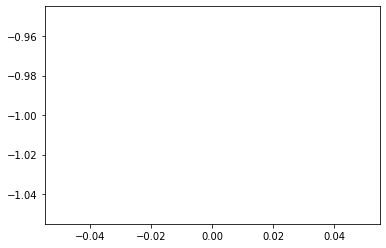

Episode 1 - total reward:1.0 moves:1

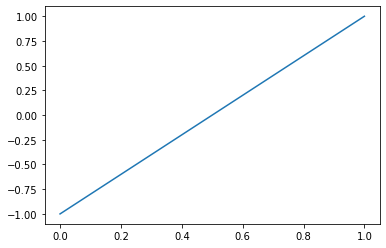

Episode 2 - total reward:-1.0 moves:1

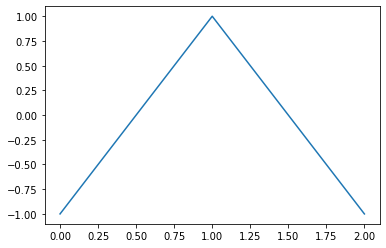

Episode 3 - total reward:1.0 moves:1

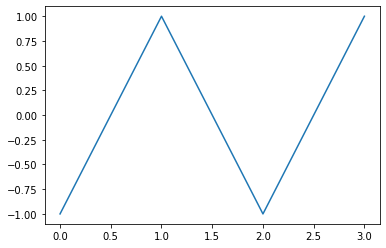

Episode 4 - total reward:1.0 moves:1

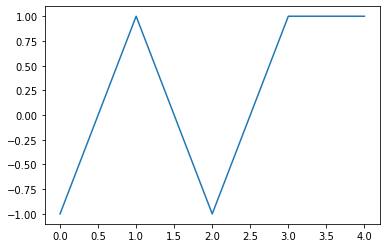

Episode 5 - total reward:-1.0 moves:3

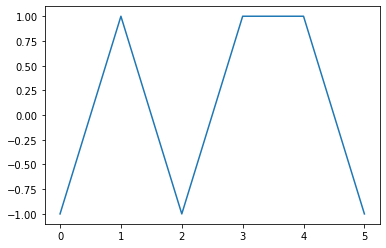

Episode 6 - total reward:-1.0 moves:1

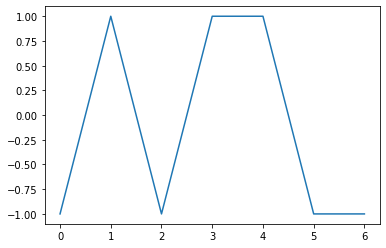

Episode 7 - total reward:-1.0 moves:3

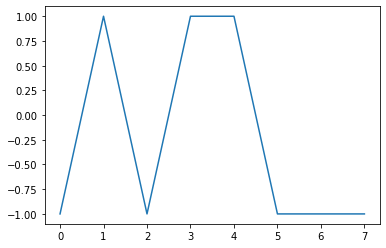

Episode 8 - total reward:-1.0 moves:2

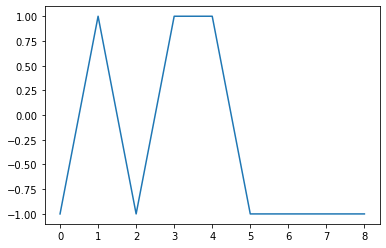

Episode 9 - total reward:-1.0 moves:1

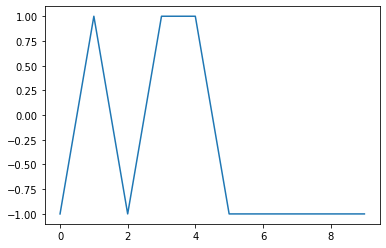

Episode 10 - total reward:-1.0 moves:1

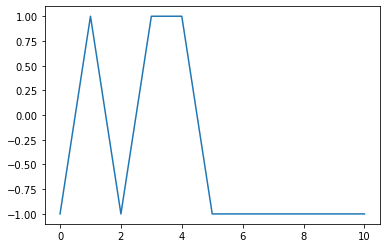

Episode 11 - total reward:-1.0 moves:2

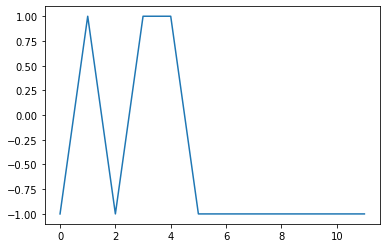

Episode 12 - total reward:-1.0 moves:1

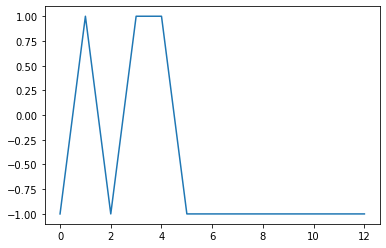

Episode 13 - total reward:-1.0 moves:1

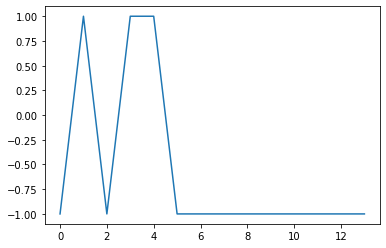

Episode 14 - total reward:1.0 moves:3

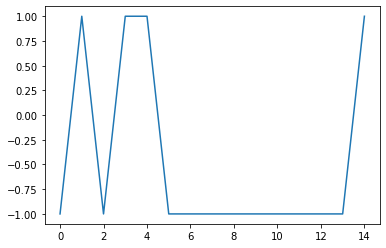

Episode 15 - total reward:-1.0 moves:1

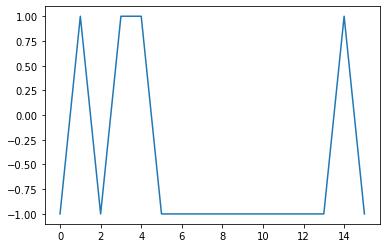

Episode 16 - total reward:-1.0 moves:1

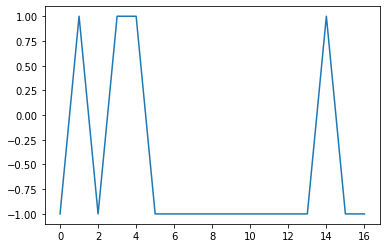

Episode 17 - total reward:-1.0 moves:2

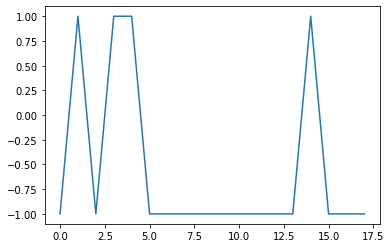

Episode 18 - total reward:-1.0 moves:1

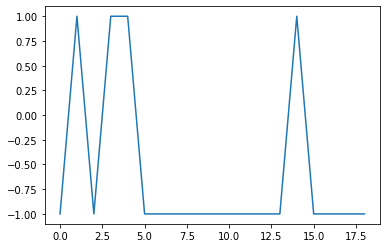

Episode 19 - total reward:-1.0 moves:1

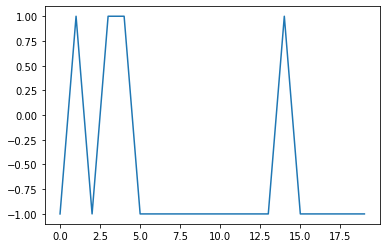

Episode 20 - total reward:0.0 moves:2WARNING:tensorflow:Model was constructed with shape (None, 1, 3) for input KerasTensor(type_spec=TensorSpec(shape=(None, 1, 3), dtype=tf.float32, name='dense_input'), name='dense_input', description="created by layer 'dense_input'"), but it was called on an input with incompatible shape (32, 3).
Episode 20 - total reward:1.0 moves:3

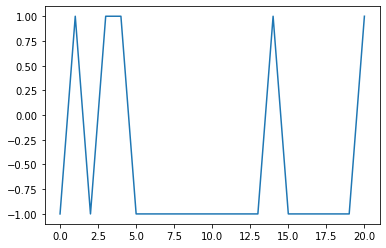

Episode 21 - total reward:-1.0 moves:1

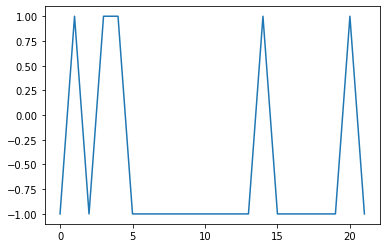

Episode 22 - total reward:-1.0 moves:5

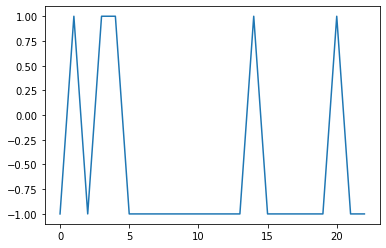

Episode 23 - total reward:-1.0 moves:1

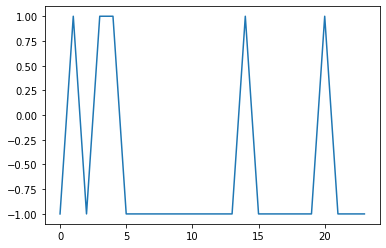

Episode 24 - total reward:-1.0 moves:1

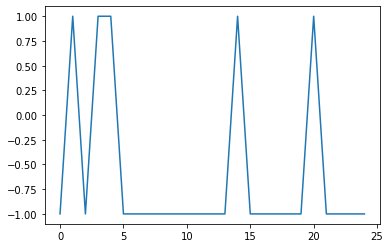

Episode 25 - total reward:-1.0 moves:2

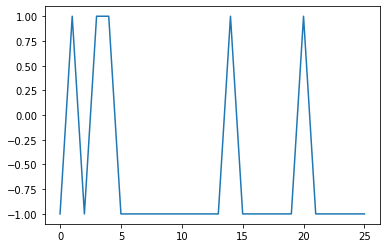

Episode 26 - total reward:-1.0 moves:2

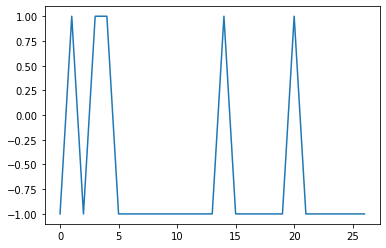

Episode 27 - total reward:-1.0 moves:2

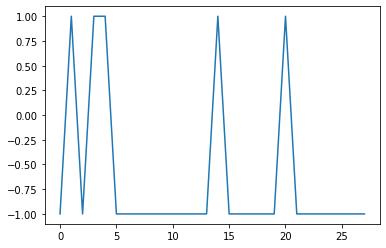

Episode 28 - total reward:-1.0 moves:2

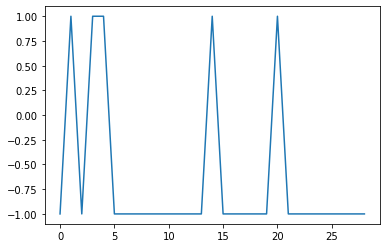

Episode 29 - total reward:-1.0 moves:3

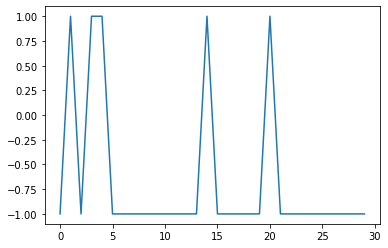

Episode 30 - total reward:-1.0 moves:1

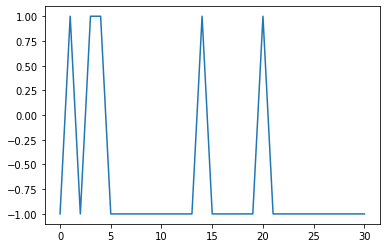

Episode 31 - total reward:1.0 moves:2

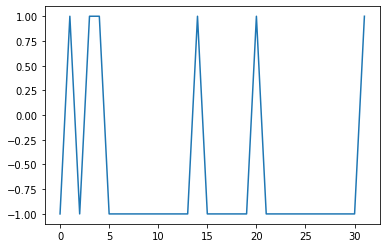

Episode 32 - total reward:-1.0 moves:1

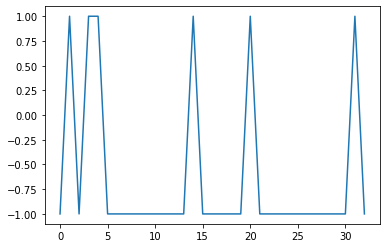

Episode 33 - total reward:-1.0 moves:1

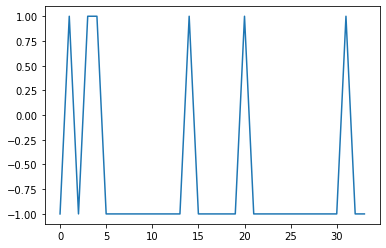

Episode 34 - total reward:-1.0 moves:2

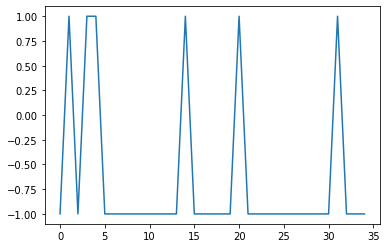

Episode 35 - total reward:1.0 moves:2

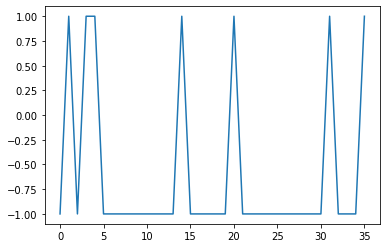

Episode 36 - total reward:-1.0 moves:2

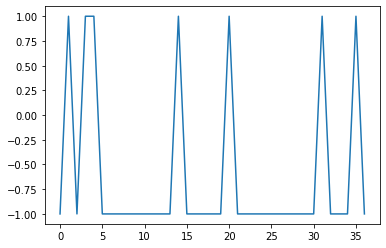

Episode 37 - total reward:1.0 moves:2

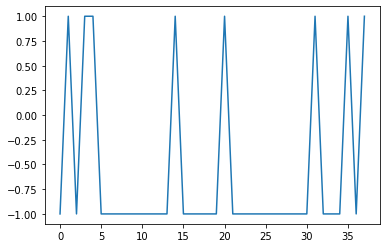

Episode 38 - total reward:-1.0 moves:1

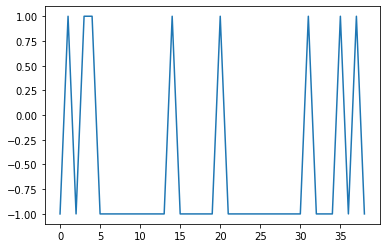

Episode 39 - total reward:-1.0 moves:3

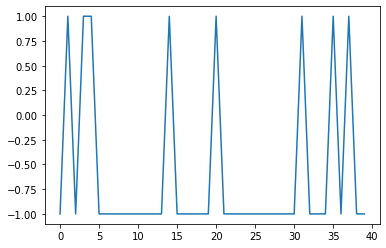

Episode 40 - total reward:-1.0 moves:1

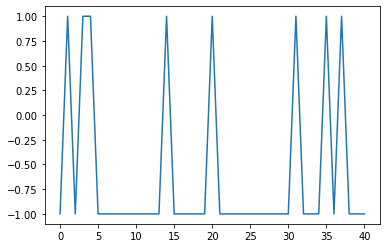

Episode 41 - total reward:-1.0 moves:2

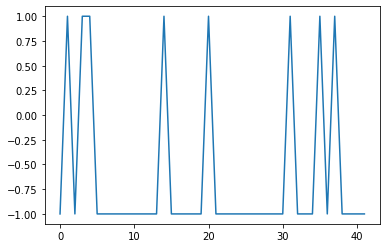

Episode 42 - total reward:-1.0 moves:1

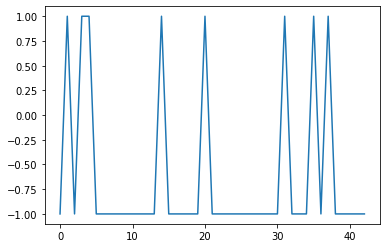

Episode 43 - total reward:-1.0 moves:2

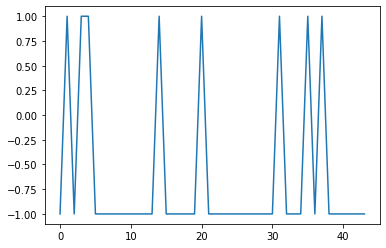

Episode 44 - total reward:-1.0 moves:1

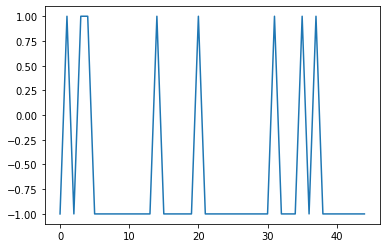

Episode 45 - total reward:1.0 moves:2

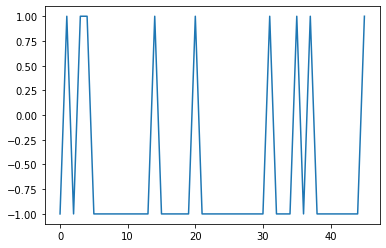

Episode 46 - total reward:-1.0 moves:3

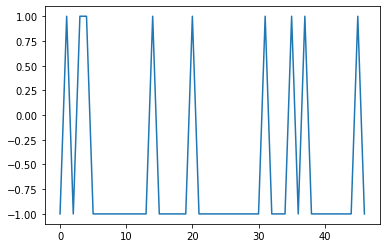

Episode 47 - total reward:-1.0 moves:1

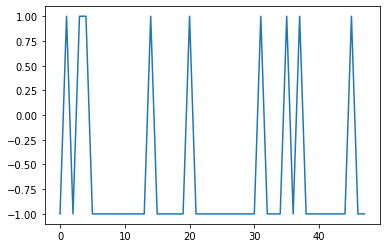

Episode 48 - total reward:-1.0 moves:3

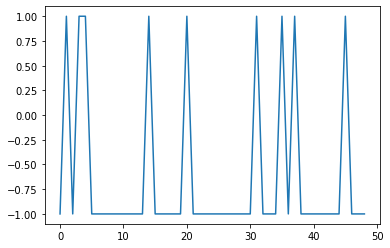

Episode 49 - total reward:-1.0 moves:1

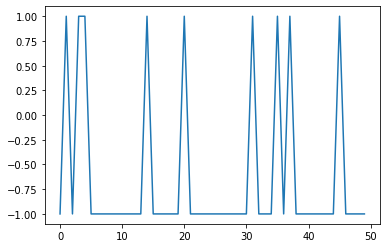

Episode 50 - total reward:-1.0 moves:1

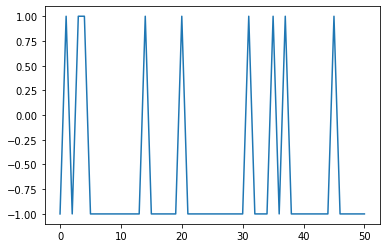

Episode 51 - total reward:-1.0 moves:3

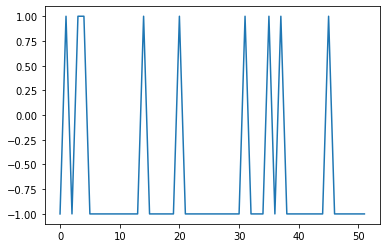

Episode 52 - total reward:-1.0 moves:1

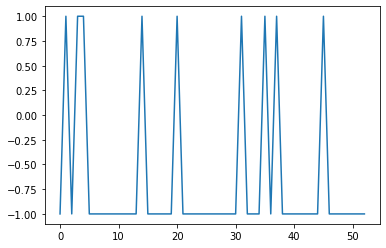

Episode 53 - total reward:-1.0 moves:3

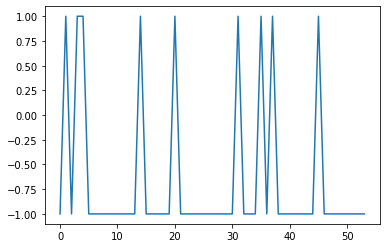

Episode 54 - total reward:1.0 moves:2

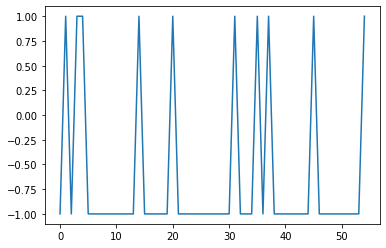

Episode 55 - total reward:-1.0 moves:2

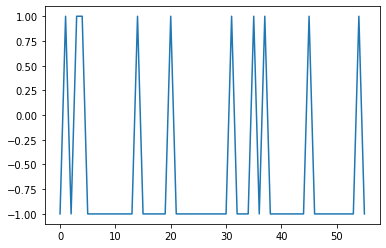

Episode 56 - total reward:0.0 moves:2

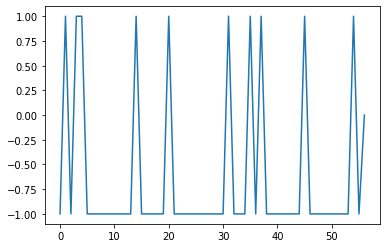

Episode 57 - total reward:-1.0 moves:1

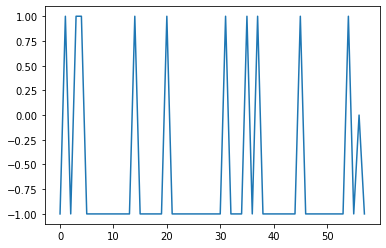

Episode 58 - total reward:-1.0 moves:1

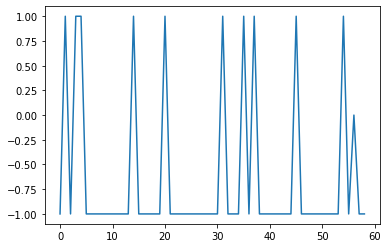

Episode 59 - total reward:-1.0 moves:2

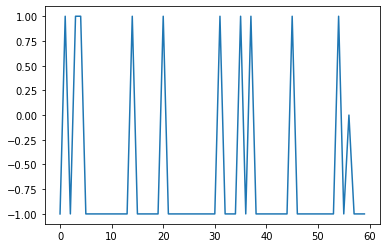

Episode 60 - total reward:-1.0 moves:2

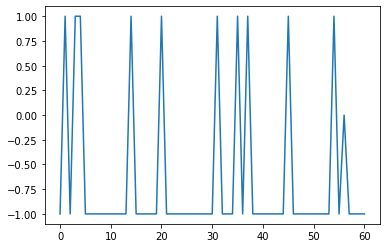

Episode 61 - total reward:-1.0 moves:1

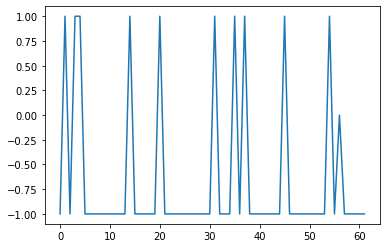

Episode 62 - total reward:-1.0 moves:1

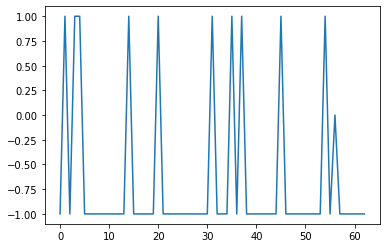

Episode 63 - total reward:-1.0 moves:2

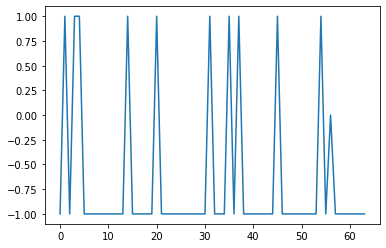

Episode 64 - total reward:-1.0 moves:2

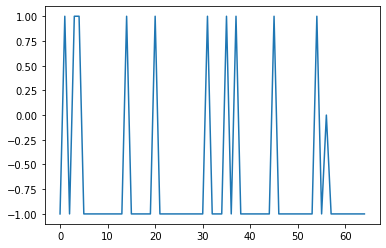

Episode 65 - total reward:-1.0 moves:2

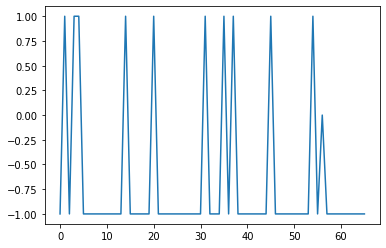

Episode 66 - total reward:-1.0 moves:2

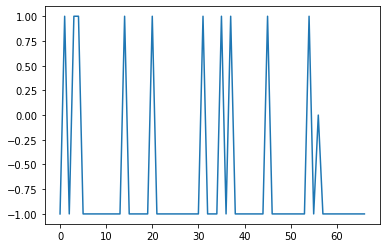

Episode 67 - total reward:-1.0 moves:1

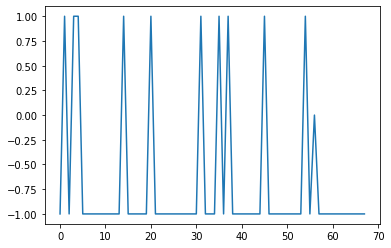

Episode 68 - total reward:-1.0 moves:2

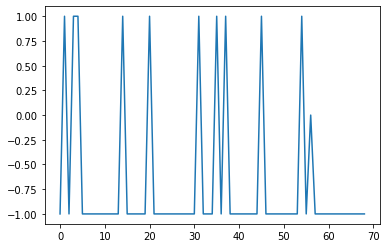

Episode 69 - total reward:-1.0 moves:1

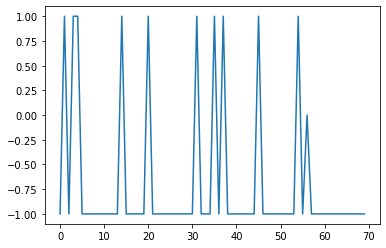

Episode 70 - total reward:1.0 moves:2

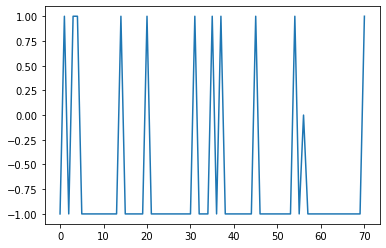

Episode 71 - total reward:-1.0 moves:1

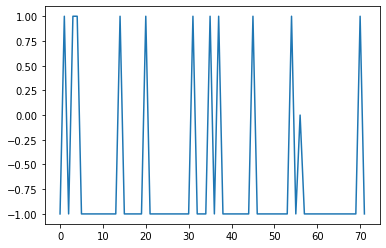

Episode 72 - total reward:1.0 moves:2

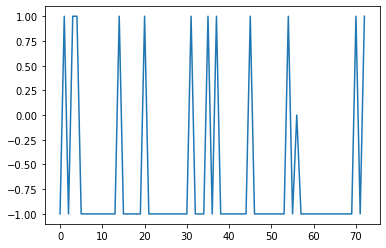

Episode 73 - total reward:-1.0 moves:1

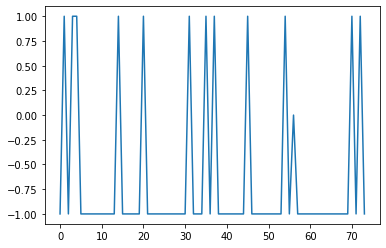

Episode 74 - total reward:-1.0 moves:1

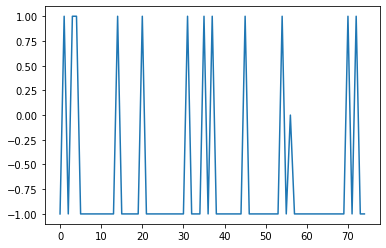

Episode 75 - total reward:-1.0 moves:2

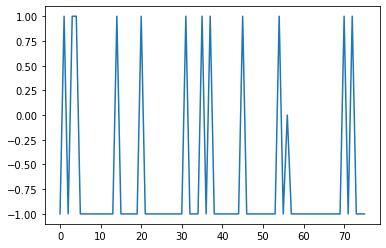

Episode 76 - total reward:-1.0 moves:2

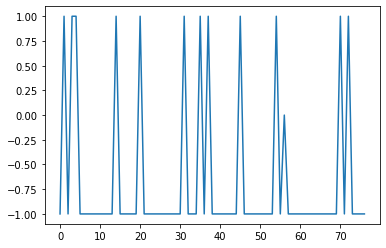

Episode 77 - total reward:-1.0 moves:1

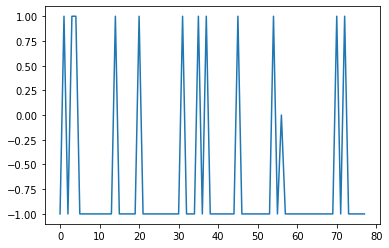

Episode 78 - total reward:-1.0 moves:2

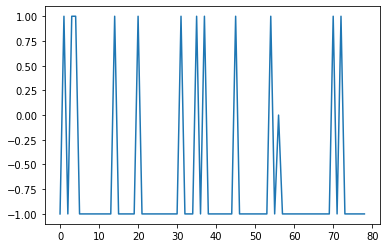

Episode 79 - total reward:0.0 moves:2

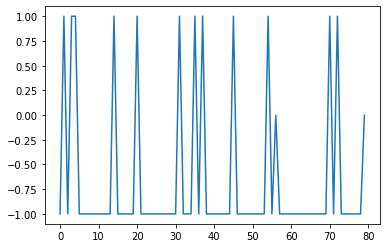

Episode 80 - total reward:-1.0 moves:2

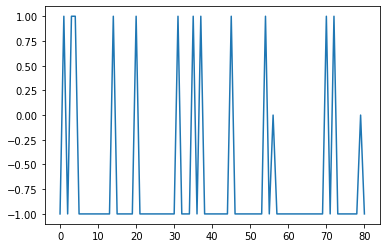

Episode 81 - total reward:-1.0 moves:1

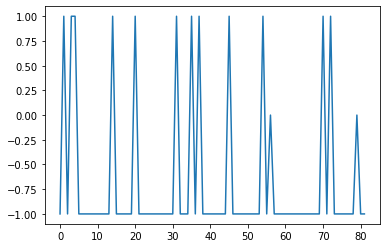

Episode 82 - total reward:-1.0 moves:1

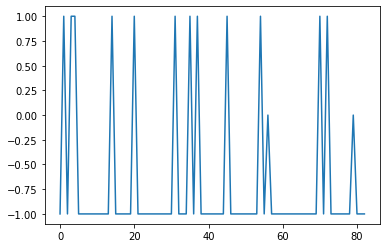

Episode 83 - total reward:-1.0 moves:1

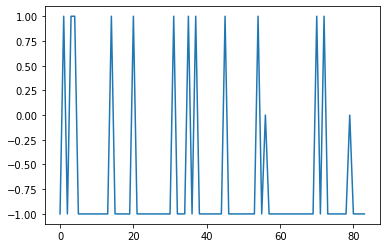

Episode 84 - total reward:-1.0 moves:2

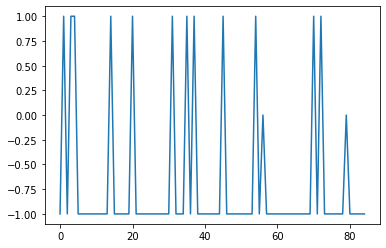

Episode 85 - total reward:-1.0 moves:3

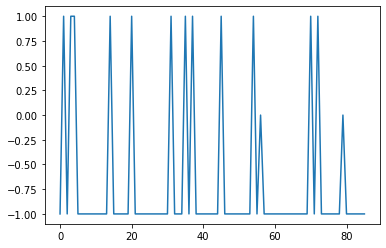

Episode 86 - total reward:-1.0 moves:2

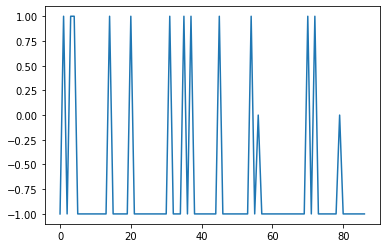

Episode 87 - total reward:0.0 moves:2

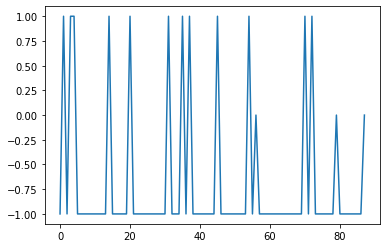

Episode 88 - total reward:-1.0 moves:2

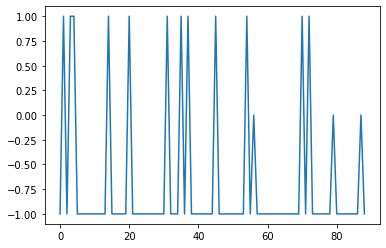

Episode 89 - total reward:-1.0 moves:1

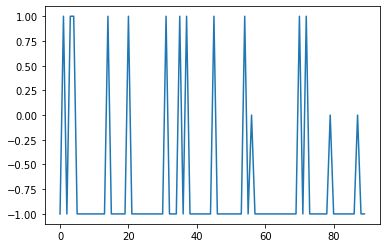

Episode 90 - total reward:0.0 moves:2

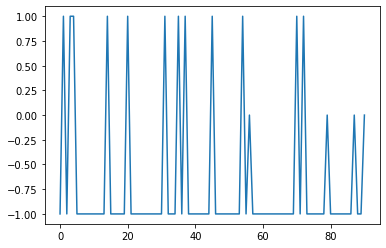

Episode 91 - total reward:1.0 moves:2

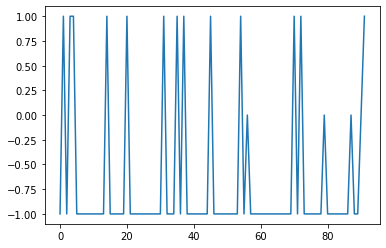

Episode 92 - total reward:-1.0 moves:1

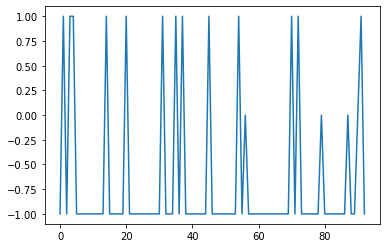

Episode 93 - total reward:-1.0 moves:2

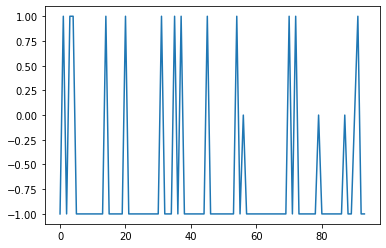

Episode 94 - total reward:1.0 moves:3

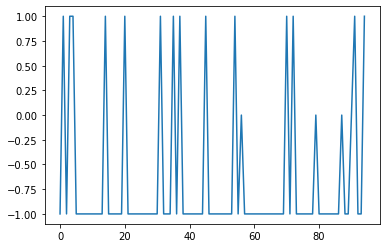

Episode 95 - total reward:-1.0 moves:3

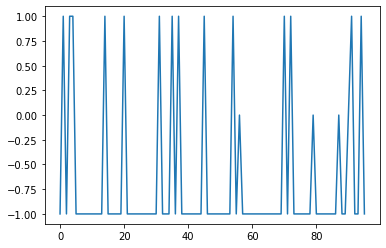

Episode 96 - total reward:-1.0 moves:2

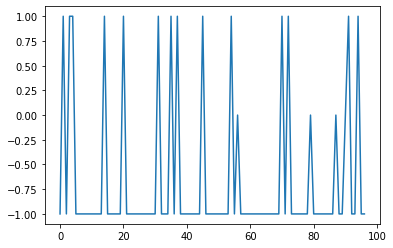

Episode 97 - total reward:1.0 moves:2

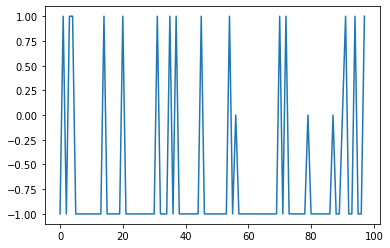

Episode 98 - total reward:-1.0 moves:2

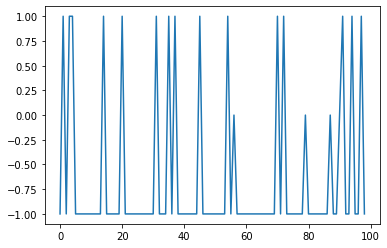

Episode 99 - total reward:1.0 moves:2

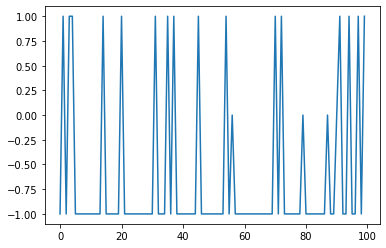

Episode 100 - total reward:-1.0 moves:1

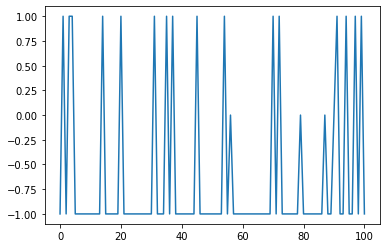

Episode 101 - total reward:-1.0 moves:2

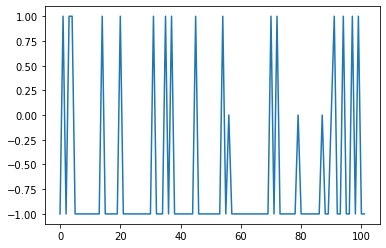

Episode 102 - total reward:1.0 moves:2

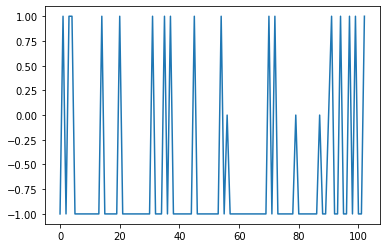

Episode 103 - total reward:-1.0 moves:1

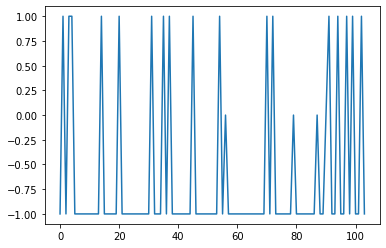

Episode 104 - total reward:1.0 moves:2

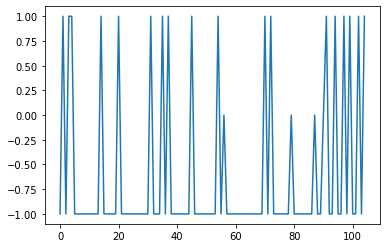

Episode 105 - total reward:1.0 moves:2

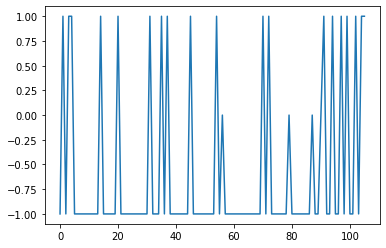

Episode 106 - total reward:-1.0 moves:1

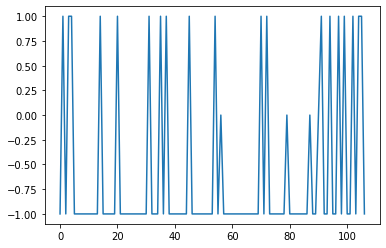

Episode 107 - total reward:-1.0 moves:3

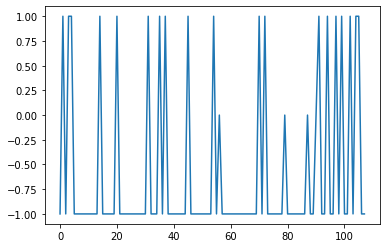

Episode 108 - total reward:-1.0 moves:1

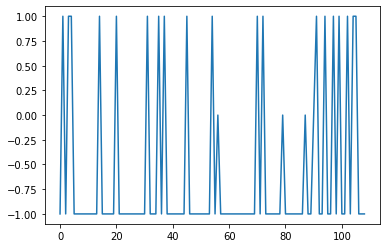

Episode 109 - total reward:1.0 moves:2

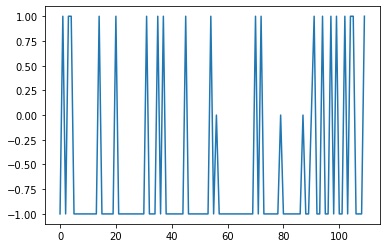

Episode 110 - total reward:1.0 moves:3

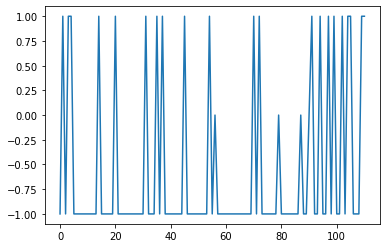

Episode 111 - total reward:1.0 moves:2

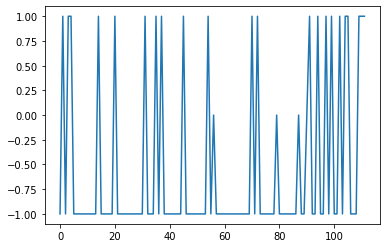

Episode 112 - total reward:1.0 moves:2

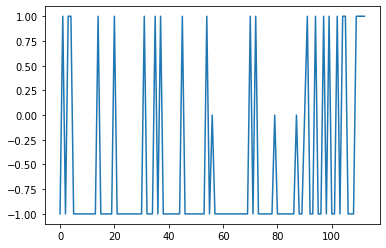

Episode 113 - total reward:1.0 moves:2

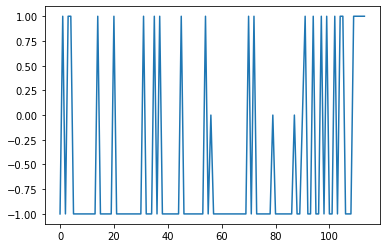

Episode 114 - total reward:-1.0 moves:2

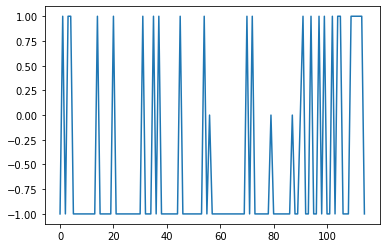

Episode 115 - total reward:1.0 moves:3

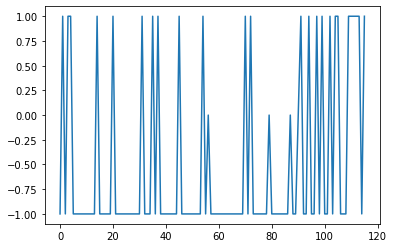

Episode 116 - total reward:1.0 moves:2

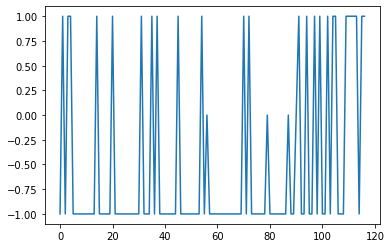

Episode 117 - total reward:-1.0 moves:2

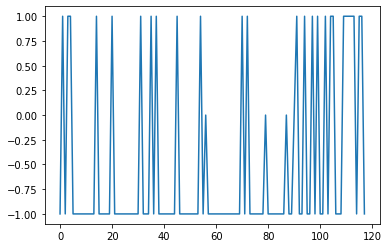

Episode 118 - total reward:1.0 moves:2

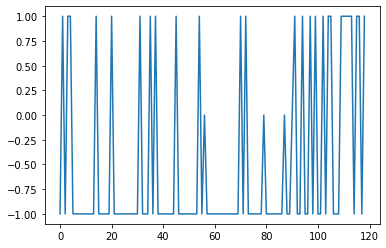

Episode 119 - total reward:-1.0 moves:1

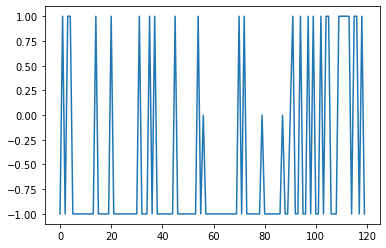

Episode 120 - total reward:-1.0 moves:3

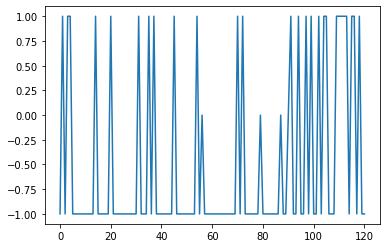

Episode 121 - total reward:-1.0 moves:2

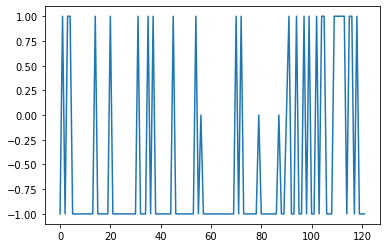

Episode 122 - total reward:-1.0 moves:2

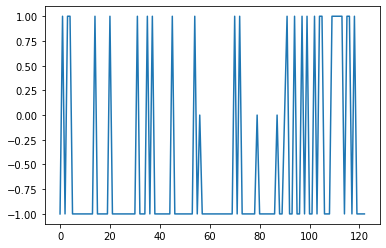

Episode 123 - total reward:-1.0 moves:2

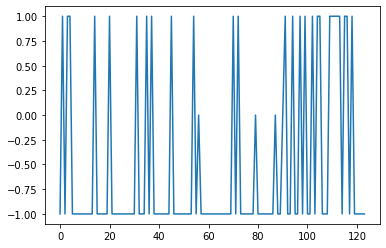

Episode 124 - total reward:-1.0 moves:1

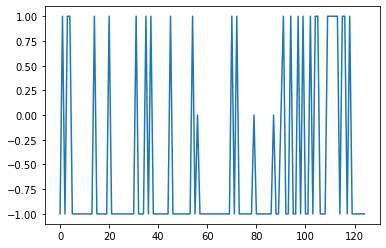

Episode 125 - total reward:1.0 moves:2

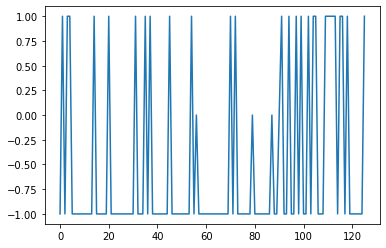

Episode 126 - total reward:-1.0 moves:2

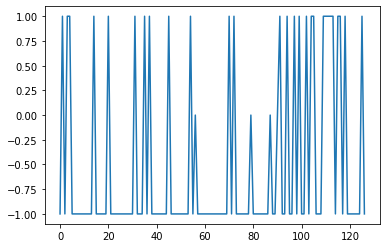

Episode 127 - total reward:-1.0 moves:1

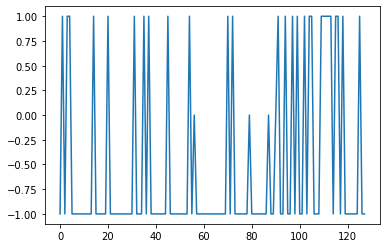

Episode 128 - total reward:-1.0 moves:3

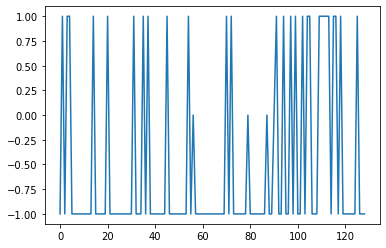

Episode 129 - total reward:-1.0 moves:1

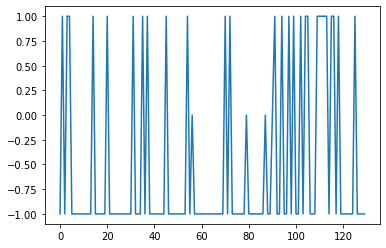

Episode 130 - total reward:1.0 moves:2

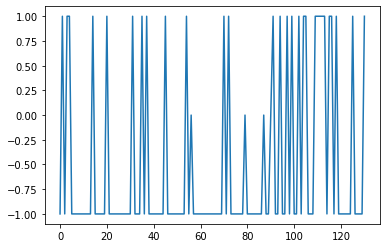

Episode 131 - total reward:0.0 moves:2

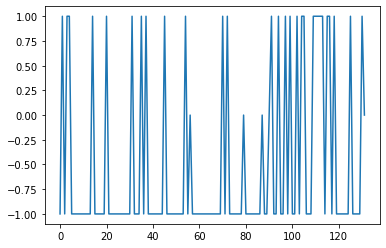

Episode 132 - total reward:-1.0 moves:2

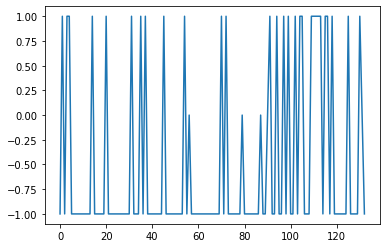

Episode 133 - total reward:-1.0 moves:2

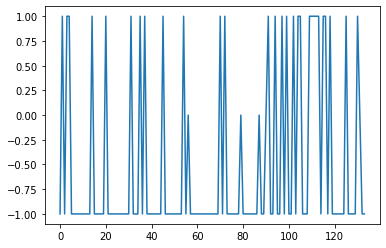

Episode 134 - total reward:-1.0 moves:1

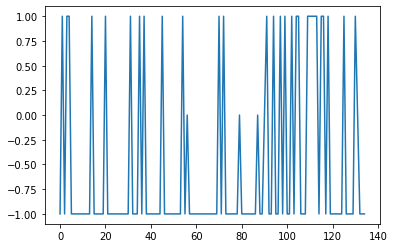

Episode 135 - total reward:-1.0 moves:1

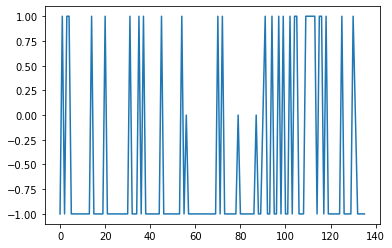

Episode 136 - total reward:-1.0 moves:1

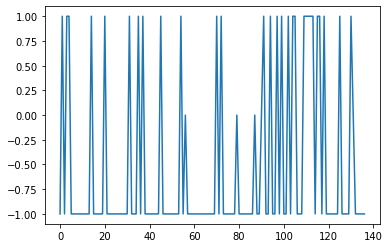

Episode 137 - total reward:1.0 moves:2

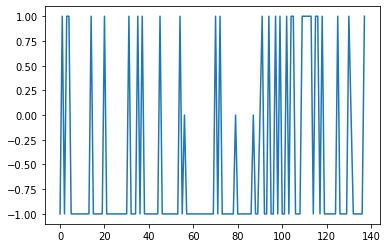

Episode 138 - total reward:1.0 moves:2

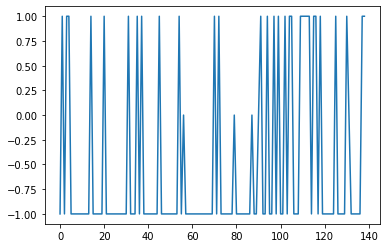

Episode 139 - total reward:-1.0 moves:1

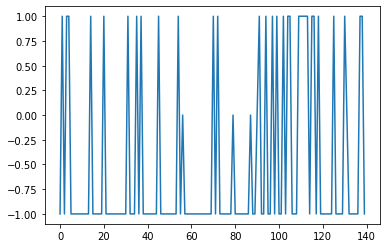

Episode 140 - total reward:-1.0 moves:2

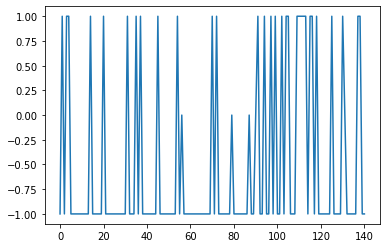

Episode 141 - total reward:-1.0 moves:2

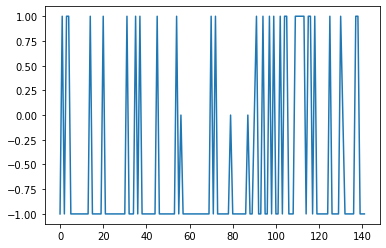

Episode 142 - total reward:-1.0 moves:1

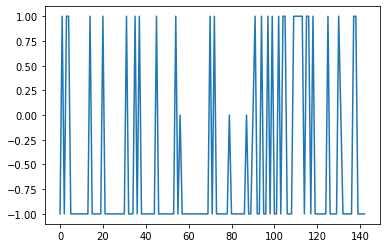

Episode 143 - total reward:-1.0 moves:1

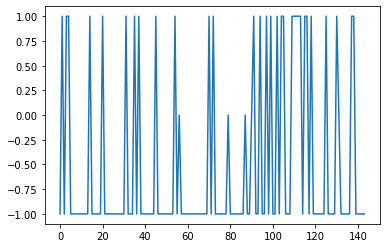

Episode 144 - total reward:-1.0 moves:3

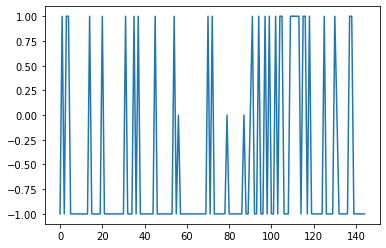

Episode 145 - total reward:1.0 moves:2

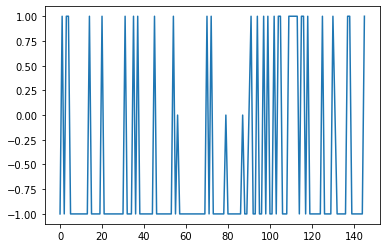

Episode 146 - total reward:-1.0 moves:1

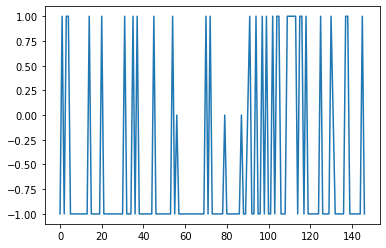

Episode 147 - total reward:-1.0 moves:1

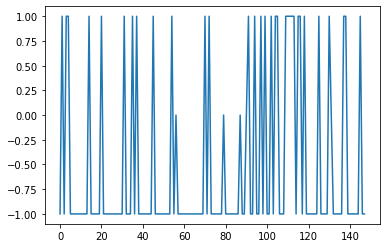

Episode 148 - total reward:-1.0 moves:1

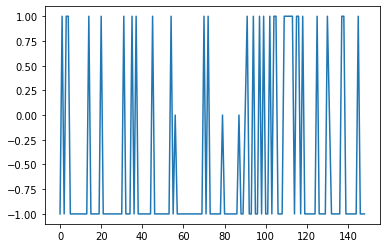

Episode 149 - total reward:1.0 moves:3

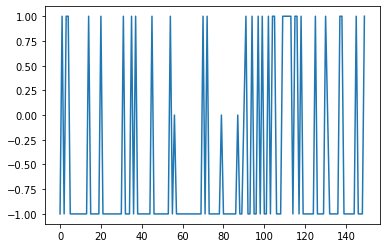

Episode 150 - total reward:-1.0 moves:1

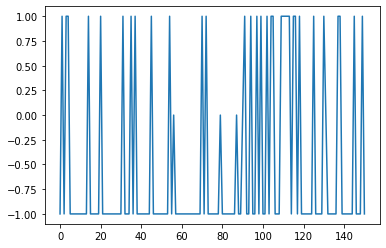

Episode 151 - total reward:-1.0 moves:2

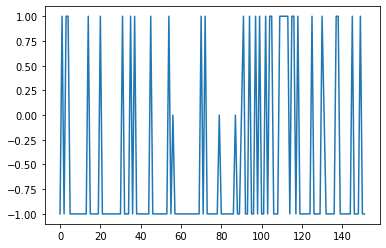

Episode 152 - total reward:-1.0 moves:2

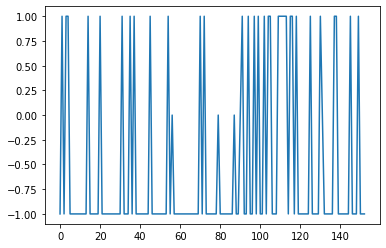

Episode 153 - total reward:-1.0 moves:2

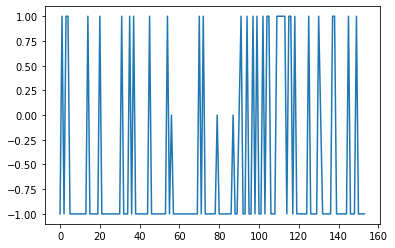

Episode 154 - total reward:1.0 moves:2

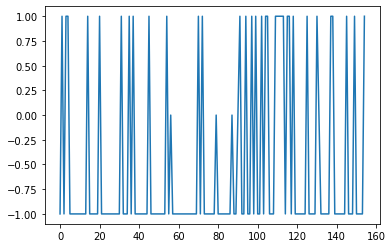

Episode 155 - total reward:-1.0 moves:2

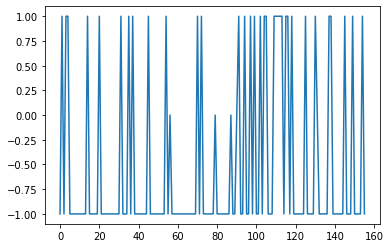

Episode 156 - total reward:-1.0 moves:2

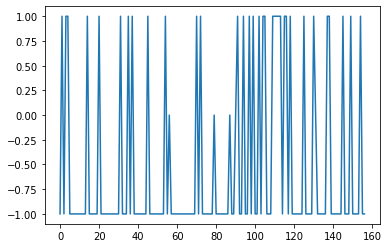

Episode 157 - total reward:-1.0 moves:1

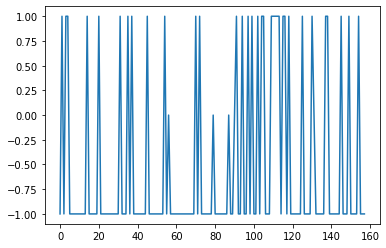

Episode 158 - total reward:0.0 moves:2

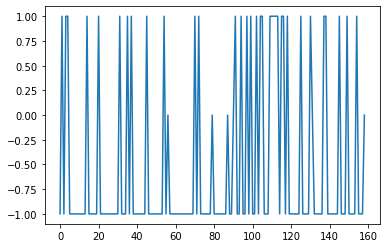

Episode 159 - total reward:-1.0 moves:1

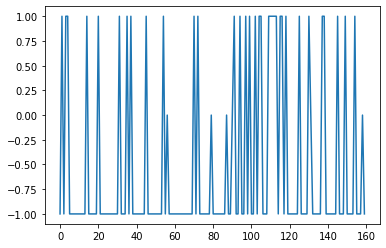

Episode 160 - total reward:-1.0 moves:1

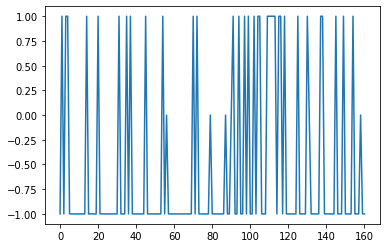

Episode 161 - total reward:-1.0 moves:2

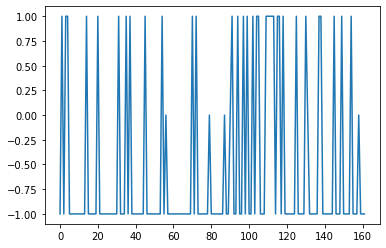

Episode 162 - total reward:1.0 moves:2

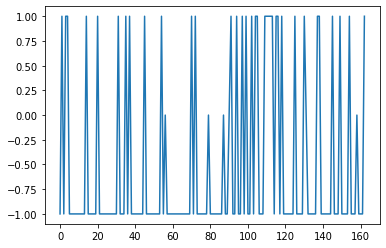

Episode 163 - total reward:-1.0 moves:1

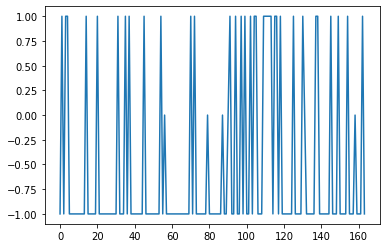

Episode 164 - total reward:1.0 moves:2

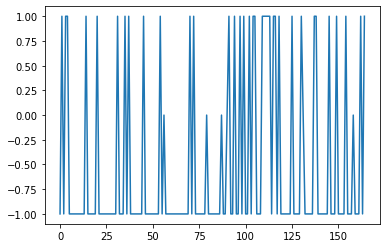

Episode 165 - total reward:-1.0 moves:1

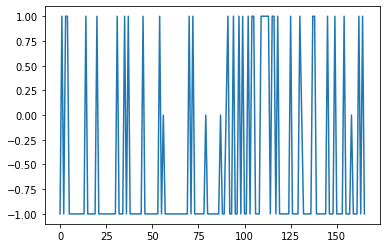

Episode 166 - total reward:-1.0 moves:1

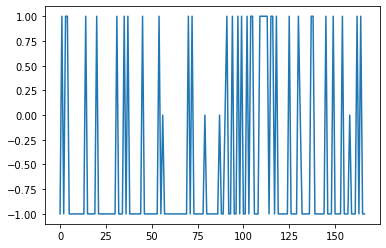

Episode 167 - total reward:-1.0 moves:2

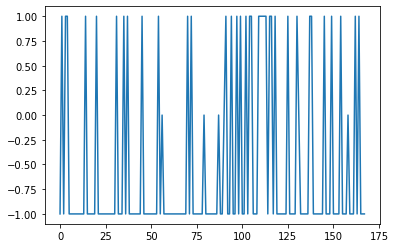

Episode 168 - total reward:-1.0 moves:1

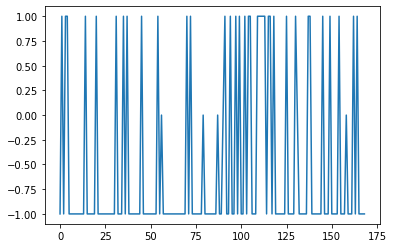

Episode 169 - total reward:-1.0 moves:2

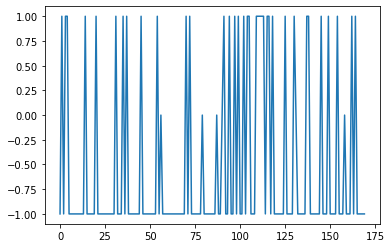

Episode 170 - total reward:-1.0 moves:1

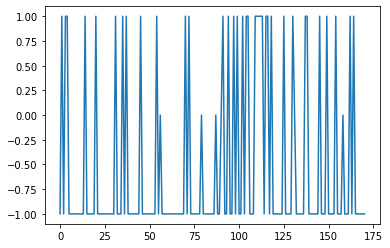

Episode 171 - total reward:-1.0 moves:2

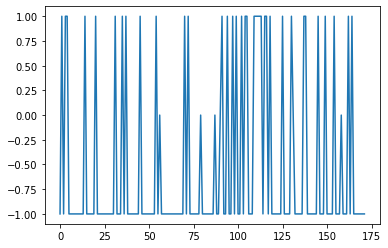

Episode 172 - total reward:-1.0 moves:1

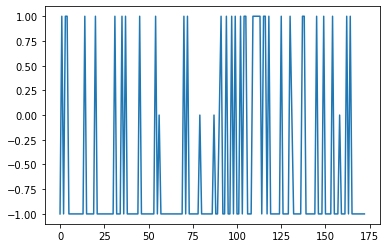

Episode 173 - total reward:-1.0 moves:1

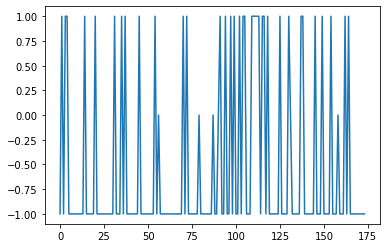

Episode 174 - total reward:-1.0 moves:1

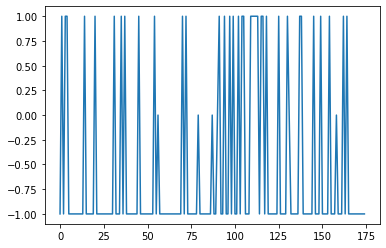

Episode 175 - total reward:-1.0 moves:2

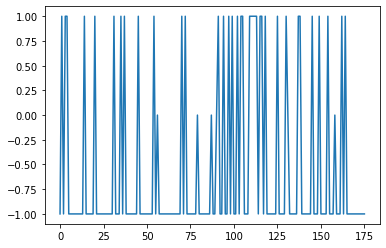

Episode 176 - total reward:1.0 moves:2

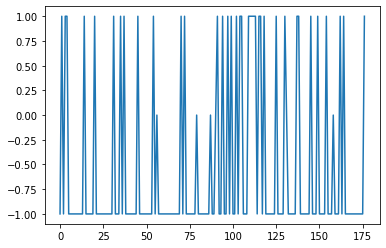

Episode 177 - total reward:-1.0 moves:1

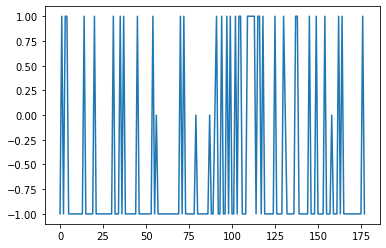

Episode 178 - total reward:-1.0 moves:2

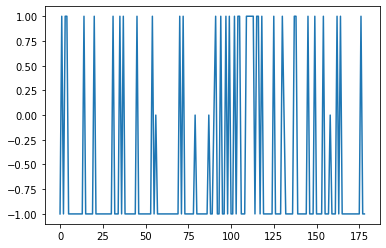

Episode 179 - total reward:-1.0 moves:2

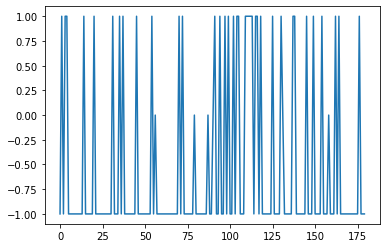

Episode 180 - total reward:1.0 moves:3

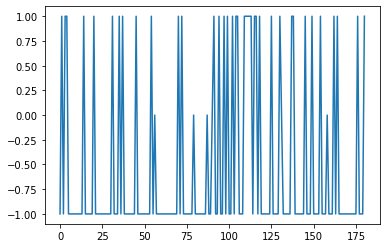

Episode 181 - total reward:-1.0 moves:2

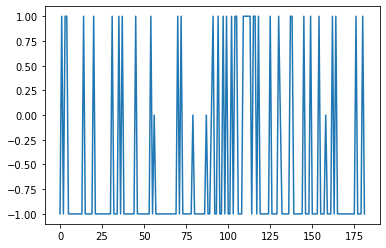

Episode 182 - total reward:-1.0 moves:2

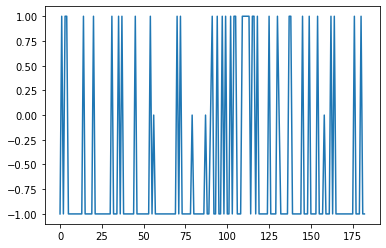

Episode 183 - total reward:-1.0 moves:1

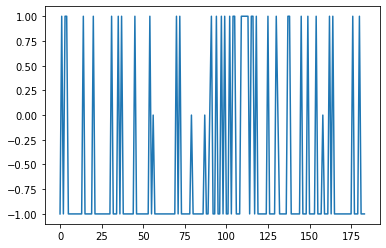

Episode 184 - total reward:-1.0 moves:2

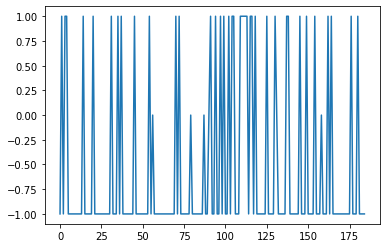

Episode 185 - total reward:-1.0 moves:1

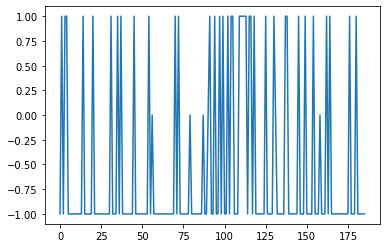

Episode 186 - total reward:1.0 moves:2

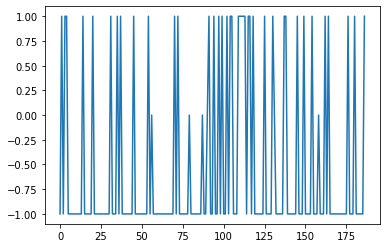

Episode 187 - total reward:0.0 moves:2

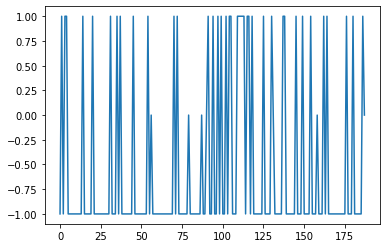

Episode 188 - total reward:-1.0 moves:1

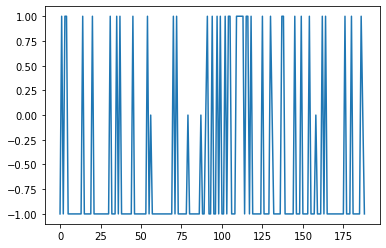

Episode 189 - total reward:0.0 moves:2

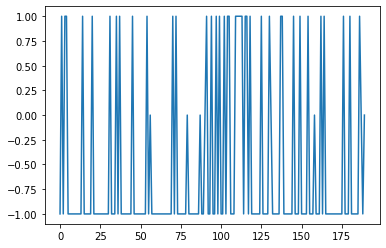

Episode 190 - total reward:-1.0 moves:2

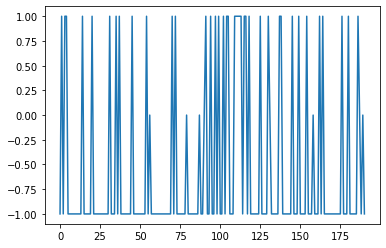

Episode 191 - total reward:-1.0 moves:1

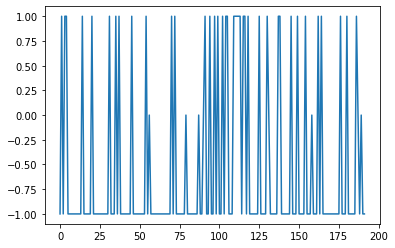

Episode 192 - total reward:-1.0 moves:3

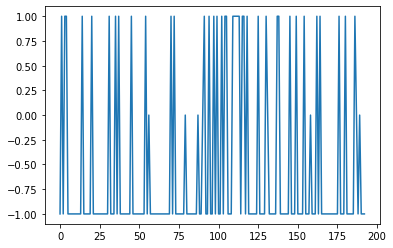

Episode 193 - total reward:-1.0 moves:1

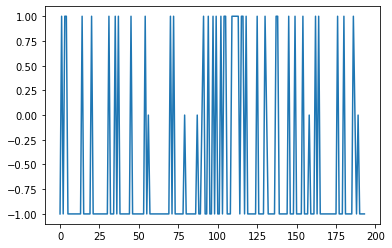

Episode 194 - total reward:-1.0 moves:1

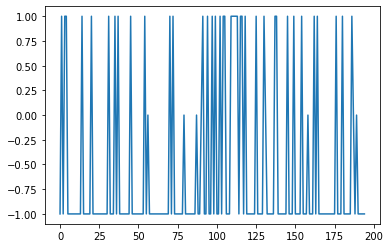

Episode 195 - total reward:-1.0 moves:4

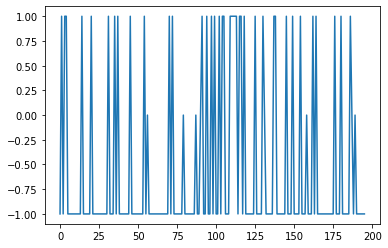

Episode 196 - total reward:-1.0 moves:1

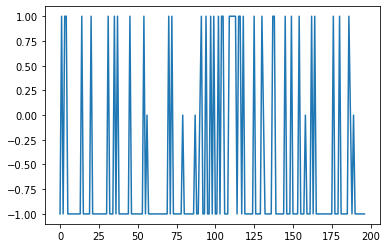

Episode 197 - total reward:-1.0 moves:2

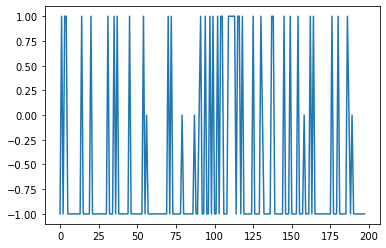

Episode 198 - total reward:-1.0 moves:1

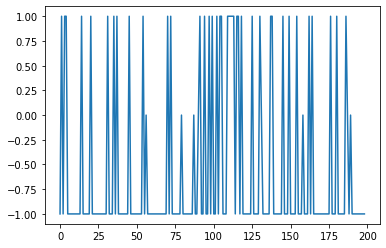

Episode 199 - total reward:1.0 moves:2

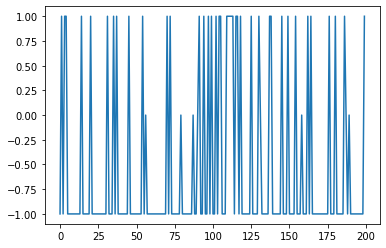

Episode 200 - total reward:0.0 moves:2

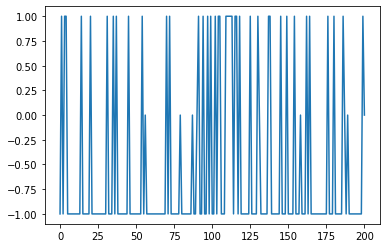

Episode 201 - total reward:-1.0 moves:1

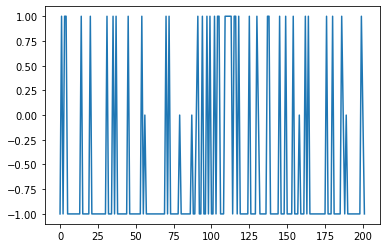

Episode 202 - total reward:1.0 moves:2

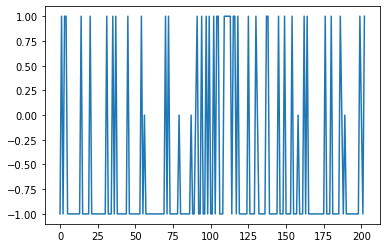

Episode 203 - total reward:-1.0 moves:3

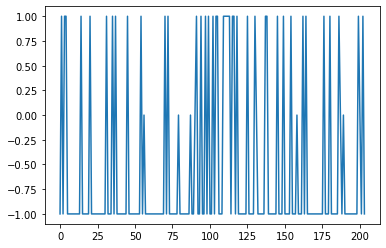

Episode 204 - total reward:-1.0 moves:1

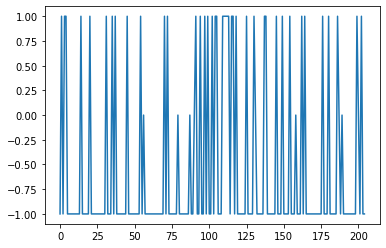

Episode 205 - total reward:-1.0 moves:1

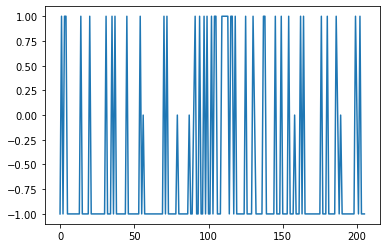

Episode 206 - total reward:1.0 moves:2

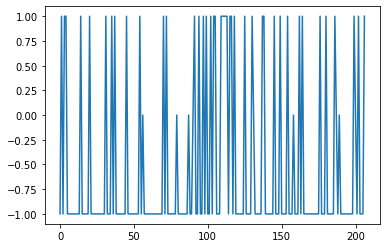

Episode 207 - total reward:-1.0 moves:2

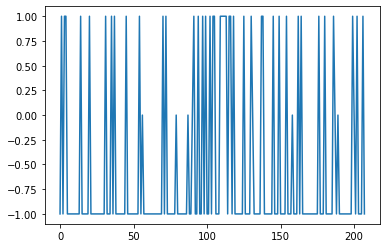

Episode 208 - total reward:-1.0 moves:2

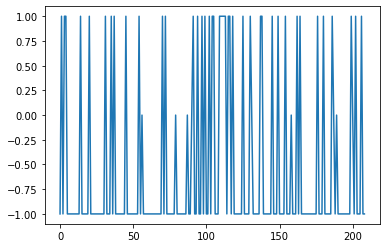

Episode 209 - total reward:-1.0 moves:2

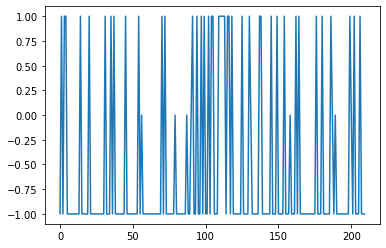

Episode 210 - total reward:0.0 moves:2

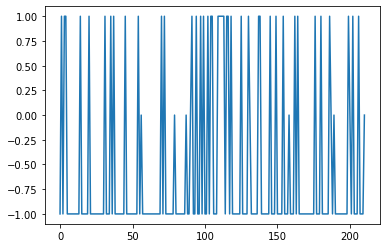

Episode 211 - total reward:-1.0 moves:3

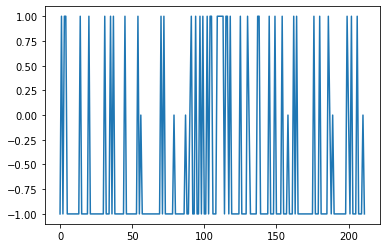

Episode 212 - total reward:-1.0 moves:2

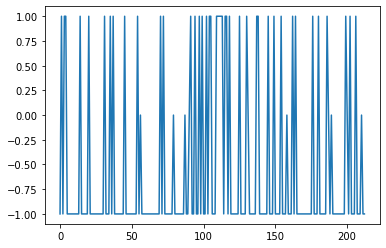

Episode 213 - total reward:-1.0 moves:3

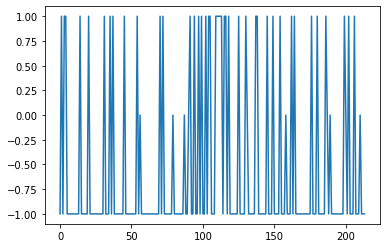

Episode 214 - total reward:-1.0 moves:2

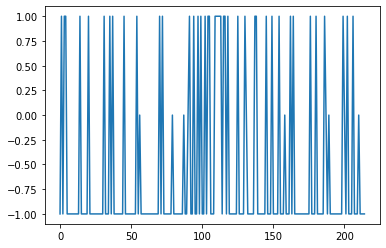

Episode 215 - total reward:1.0 moves:2

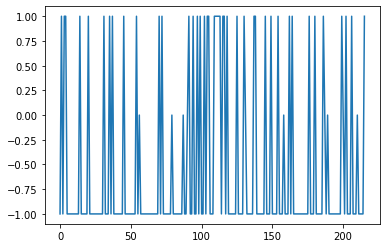

Episode 216 - total reward:1.0 moves:2

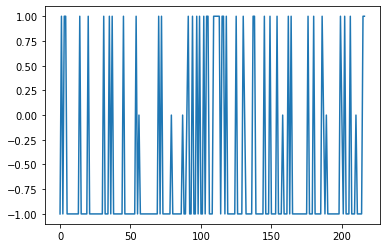

Episode 217 - total reward:-1.0 moves:2

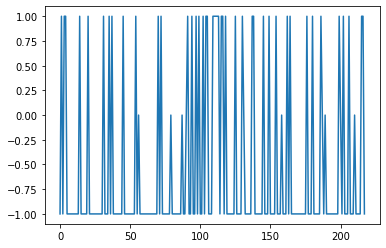

In [ ]:
engine = Engine(1000, 'Blackjack-v0', 0.001)
engine.train(training_epochs=1000, target_change = 10)